In [1]:
%pylab inline 
import torch 
import torch.nn as nn 
import torch.nn.functional as F
from tqdm import trange 
from utils import *
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

Populating the interactive namespace from numpy and matplotlib
torch.Size([4, 1, 57])


In [33]:
class LSTMCell(nn.Module):
    def __init__(self, in_size, h_size):
        super(LSTMCell, self).__init__()
        self.h_size = h_size
        self.fg = nn.Linear(in_size + h_size, h_size)
        self.in_g = nn.Linear(in_size + h_size, h_size)
        self.out_g = nn.Linear(in_size + h_size, h_size)
        self.c_g = nn.Linear(in_size + h_size, h_size)
    
    def forward(self, x, h, c):
        combined = torch.cat((x, h), 1)
        c_1 = F.sigmoid(self.fg(combined)) * c 
        c_2 = F.sigmoid(self.in_g(combined)) * F.tanh(self.c_g(combined))
        c = c_1 + c_2
        out_gate = F.sigmoid(self.out_g(combined))
        h = out_gate * F.tanh(c)
        return (h, c)
    
class LSTM(nn.Module):
    def __init__(self, in_size, h_size, out_size):
        super(LSTM, self).__init__()
        self.h_size = h_size
        self.cell = LSTMCell(in_size, h_size)
        self.class_layer = nn.Linear(h_size, out_size)
    
    def forward(self, x, h, c): # Init a c and h when instantiating 
        h_out, c_out = self.cell(x, h, c)
        out = self.class_layer(h_out)
        return out, h_out, c_out
    
    def init_h_states(self):
        return torch.zeros(1, self.h_size)

lstm = LSTM(n_chars,128, n_categs)

In [35]:
# Training Function 
opt = torch.optim.Adam(lstm.parameters())
loss_function = nn.CrossEntropyLoss()
def train(categ_tensor, line_tensor):
    h = lstm.init_h_states()
    c = lstm.init_h_states()
    
    for i in range(line_tensor.size(0)):
        out, h, c = lstm(line_tensor[i], h, c)
    loss = loss_function(out, categ_tensor)
    # Update Weights 
    opt.zero_grad()
    loss.backward()
    opt.step()
    return out, loss.item()

100%|██████████| 100001/100001 [04:53<00:00, 340.66it/s] loss = 0.295 Lee Korean / CORRECT



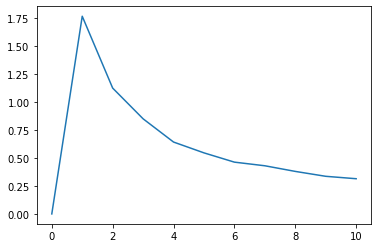

In [36]:
epochs = 100000
steps = epochs / 10 
plot_steps = epochs / 10 
losses = []
c_loss = 0
for i in trange(epochs+1):
    categ, line, categ_tensor, line_tensor = gen_rand_training_example()
    out, loss = train(categ_tensor, line_tensor)
    c_loss += loss 

    if i % steps == 0:
        guess, guess_i = categ_from_out(out)
        correct = "CORRECT" if guess == categ else f"WRONG ({categ})"
        print(f" loss = {loss:.3f} {line} {guess} / {correct}")
    if i % plot_steps == 0:
        losses.append(c_loss / plot_steps)
        c_loss = 0
plot(losses)



    
